# 2D Multi-Component Multi-Phase Lattice Boltzmann (LBM) Simulations 
__Author(s):__ Bernard Chang and Masa Prodanovic

__Last Update:__ Feb. 2026

Copyright © 2026 Digital Porous Media Team. All rights reserved.

---

In this hands-on activity, we will demonstrate the general algorithm used to perform multi-component multiphase (MCMP) lattice Boltzmann simulations. The goal of this exercise is to implement the fundamental components of the MCMP Shan-Chen model and to demonstrate how simulation parameters influence fluid behavior. This example is performed on a 2-dimensional lattice with 9 discrete velocities (D2Q9).

This notebook assumes basic understanding of lattice Boltzmann methods. For a more comprehensive review of basic concepts, please refer to the [5-2-1_lbm_d2q9_bgk](5_simulation/5-2-1_lbm_d2q9_bgk.ipynb) and [5-2-2_lbm_d2q9_scmp](5_simulation/5-2-2_lbm_d2q9_scmp.ipynb) notebooks.

Before we get started, let's import some packages


In [2]:
#@title Import Packages
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Tuple, Iterable, Optional

from functools import wraps

# Define a decorator to extend a class with new methods
def extend(cls, *, override=True):
    def decorator(func):
        if not override and hasattr(cls, func.__name__):
            raise AttributeError(
                f"{cls.__name__}.{func.__name__} already exists"
            )

        @wraps(func)
        def method(*args, **kwargs):
            return func(*args, **kwargs)

        setattr(cls, func.__name__, method)
        return method
    return decorator


## Setting up Multi-Component Multiphase (SCMP) Lattice Boltzmann Methods

### Background
As in single-phase and single-component multiphase lattice Boltzmann methods (LBM), the fundamental variable in **kinetic theory**, on which LBM is based, is the particle distribution function $f$. LBM models the mesoscopic dynamics of fluids by evolving $f$ according to the discretized Boltzmann equation. 

SCMP LBM extends this framework by introducing effective interparticle interactions that enable spontaneous phase separation into coexisting phases (liquid/vapor).

In MCMP LBM, each component has its own distribution function $f_i$. The component populations typically operate on the same lattice, but evolve (stream and collide) independently. It is further possible to assign different fluid properties (e.g., $\tau$, $\psi$) to each component. The components interact via interaction parameter, which results in Shan-Chen forces from neighboring densities and relaxation toward a common velocity.

To begin, we will define a class object called ```LBM_MCMP()``` where we will initialize several variables we need to start building our simulator, including the discrete velocity vectors and lattice weights.

***Note:*** that most parameters (e.g., $\tau$, $\psi_s$) are defined as an iterable with the same length as the number of components. The interaction strength matrix `G_mat` has shape `(n_comp, n_comp)` with zeros on the diagonal (self-interaction) and non-zero off-diagonal entries (component interactions). Field quantities (except for total velocity) are initialized to shapes `(n_comp, ...)`.

In [ ]:
class LBM_MCMP:
    """
    Multi-Component Multi-Phase Lattice Boltzmann Method using Shan-Chen Model
    Components are indexed as alpha = 0, ..., (n_comp - 1)
    """
    def __init__(self, nx: int,
                 ny: int,
                 n_comp: int = 2,
                 tau: Iterable[float] = (1.0, 1.0),
                 cs2: float = 1.0 / 3.0,
                 G_mat: Iterable[Iterable] = [[0.0, 3.0], [3.0, 0.0]],
                 rho0: Iterable[float] = [1.0, 1.0],
                 G_ads: Iterable[float] = [0.0, 0.0],
                 psi_solid: Iterable[float] = [0.5, 0.5],
                 body_force: Optional[Iterable[float]] = [0.0, 0.0]) -> None:
        """
        Initialize MCMP
        Parameters:
        ---
        nx, ny : int
            Grid dimensions
        n_comp: int
            Number of components (fluids). Default = 2
        tau: Iterable[float]
            Per-component relaxation time. Must be of length (n_comp,). Default = [1.0, 1.0] (tau = 1.0 for all components)
        cs2: float
            Speed of sound squared. Default = 1/3 for D2Q9
        G_mat: np.ndarray
            Interaction strength matrix of shape (n_comp, n_comp). G_mat[alpha, beta] is the interaction strength between component alpha and beta.
            Must be symmetric with zeros on the diagonal.
            Default = 3.0 for all off-diagonal entries (strong phase separation) and 0 on the diagonal (no self-interaction)
        rho_0: Iterable[float]
            Per-component reference density for pseudopotential function. Default = (1.0, 1.0, ..., 1.0)
        G_ads: Iterable[float]
            Per-component fluid-solid interaction strength. Default = (-0.4, -0.4, ..., -0.4)
        psi_solid: float
            Solid pseudopotential function. Default = 0.5
        body_force: Iterable[float, float]
            Force components in x and y directions. Default = (0.0, 0.0)
        """
        self.nx = nx
        self.ny = ny

        self.n_comp = n_comp
        self.tau = np.asarray(tau, dtype=np.float64)
        self.omega = 1.0 / self.tau
        assert len(self.omega) == n_comp, f"omega must be of length {n_comp}, got {len(self.omega)}"

        self.cs2 = cs2

        self.G_mat = np.asarray(G_mat, dtype=np.float64)
        assert self.G_mat.shape == (n_comp, n_comp), f"G_mat must be of shape ({n_comp}, {n_comp}), got {self.G_mat.shape}"

        self.G_ads = np.asarray(G_ads, dtype=np.float64)
        assert len(self.G_ads) == n_comp, f"G_ads must be of length {n_comp}, got {len(self.G_ads)}"


        self.c = np.array([
            [0, 0],
            [1, 0], [0, 1], [-1, 0], [0, -1],
            [1, 1], [-1, 1], [-1, -1], [1, -1]], dtype=np.int16)
        self.weights = np.array(
            [4. / 9.,
             1. / 9., 1. / 9., 1. / 9., 1. / 9.,
             1. / 36., 1. / 36., 1. / 36., 1. / 36.], dtype=np.float64)

        self.opposite = np.array(
            [0,
             3, 4, 1, 2,
             7, 8, 5, 6], dtype=np.uint8)

        # Fields
        self.rho = np.ones((n_comp, nx, ny), dtype=np.float64)

        self.rho_0 = np.asarray(rho0, dtype=np.float64)
        self.u = np.zeros((2, nx, ny), dtype=np.float64)
        self.f = np.zeros((n_comp, 9, nx, ny), dtype=np.float64)
        self.f_eq = np.zeros((n_comp, 9, nx, ny), dtype=np.float64)
        self.psi = np.empty((n_comp, nx, ny), dtype=np.float64)
        self.psi_s = np.asarray(psi_solid, dtype=np.float64)

        self.timestep = 0
        self.solid_mask = np.zeros((nx, ny), dtype=bool)
        self.rho_min_threshold = 1.e-6  # Minimum density threshold
        self.body_force = np.asarray(body_force, dtype=np.float64) # Force components

    def initialize_density_field(self, rho_init: np.ndarray, u_init: Optional[np.ndarray] = None) -> None:
        """
        Initialize simulation from arbitrary density field
        Parameters:
        ---
        rho_init: ndarray (nx, ny)
            Initial density field
        u_init: ndarray (2, nx, ny), optional
            Initial velocity field. Defaults to zero everywhere
        Returns:
        ---
        None
        """
        if rho_init.shape != (self.n_comp, self.nx, self.ny):
            raise ValueError(f"rho_init has shape {rho_init.shape}, which does not match grid shape ({self.n_comp}, {self.nx}, {self.ny})")
        self.rho = rho_init.copy().astype(np.float64)

        self.u = u_init.copy().astype(np.float64) if u_init is not None else np.zeros((2, self.nx, self.ny), dtype=np.float64)
        assert self.u.shape == (2, self.nx, self.ny), f"u_init has shape {u_init.shape}, which does not match expected (2, {self.nx}, {self.ny})"

        # Initialize equilibrium distribution
        self.psi = self.compute_pseudopotential(self.rho)
        self.f_eq = self.compute_equilibrium(self.rho, self.u)
        self.f = self.f_eq.copy()

    def set_solids_from_mask(self, solid_mask: np.ndarray) -> None:
        """
        Set solid nodes from a boolean mask
        Parameters:
        ---
        solid_mask: ndarray (nx, ny)
            Boolean array where True indicates solid nodes
        Returns:
        ---
        None
        """
        if solid_mask.shape != (self.nx, self.ny):
            raise ValueError(f"solid_mask has shape {solid_mask.shape}, which does not match grid shape ({self.nx}, {self.ny})")
        self.solid_mask = solid_mask.copy()
        # self.f_eq[:, self.solid_mask] = 0
        self.f[:, :, self.solid_mask] = 0
        self.u[:, self.solid_mask] = 0

### Obtaining Macroscopic Properties

Component-wise macroscopic properties, such as mass and momentum density, can still be can be obtained from the weighted sum (moments) of the *discrete-velocity distribution function, $f_i(x, t)$*

The mass density is given by the zeroth moment:
$$\rho^{(\sigma)} = \sum f_i^{(\sigma)},$$
and the momentum density by the first moment:
$$\rho^{(\sigma)} u^{(\sigma)} = \sum c_i f_i^{(\sigma)},$$

where $c_i$ are the discrete lattice velocities defined by the chosen lattice.

These relations are identical to those used in single-phase BGK.

In [ ]:
def compute_macroscopic(self, f: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute macroscopic density and velocity from distribution function
    Parameters:
    ---
    f: ndarray (9, nx, ny)
        Distribution function
    Returns:
    ---
    rho: ndarray (nx, ny)
        Density field
    u: ndarray (2, nx, ny)
        Velocity field
    """
    rho = np.sum(f, axis=1)  # Sum over distribution directions
    rho = np.clip(rho, self.rho_min_threshold, None)

    # Compute per-component momentum
    u = np.zeros((self.n_comp, 2, self.nx, self.ny), dtype=np.float64)

    for i in range(9):
        u[:, 0] += f[:, i] * self.c[i, 0]  # (n_comp, nx, ny)
        u[:, 1] += f[:, i] * self.c[i, 1]  # (n_comp, nx, ny)

    # Normalize per-component momentum by per-component density
    u[:, 0] /= np.maximum(rho, 1e-12)
    u[:, 1] /= np.maximum(rho, 1e-12)

    # Zero velocity in solids
    u[:, :, self.solid_mask] = 0.0

    return rho, u

### Equilibrium Calculation

In SCMP, the equilibrium distribution function retains the standard isothermal form from the BGK model. 
Recall that after collision, the distributions $f_i$ relax toward the equilibrium distribution, $f_i^{eq}$ as:

$$ f_i^{eq}(x, t) = w_i \rho \left(1 + \frac{u \cdot c_i}{c_s^2} + \frac{(u \cdot c_i)^2}{2c_s^4} - \frac{u \cdot u}{2c_s^2} \right).$$

Assuming the isothermal lattice Boltzmann equation ($p = c_s^2 \rho$) and operating in lattice units ($\Delta x = \Delta t = 1$), the equilibrium distribution function can be simplified to

$$ f_i^{eq}(x, t) = w_i \rho \left(1 + 3(u \cdot c_i) + \frac{9}{2}(u \cdot c_i)^2 - \frac{3}{2} (u \cdot u) \right).$$

**Note:** Non-ideal effects in SCMP enter through the force term. The equilibrium distribution form itself does not change from BGK.



In [ ]:
@extend(LBM_MCMP)
def compute_equilibrium(self, rho: np.ndarray, u: np.ndarray) -> np.ndarray:
    """
    Compute equilibrium distribution function
    Parameters:
    ---
    rho: ndarray (nx, ny)
        Density field
    u: ndarray (2, nx, ny)
        Velocity field
    Returns:
    ---
    f_eq: ndarray (9, nx, ny)
        Equilibrium distribution
    """
    f_eq = np.zeros_like(self.f)
    u_sq = u[0]**2 + u[1]**2
    for i in range(9):
        u_dot_c = self.c[i, 0] * u[0] + self.c[i, 1] * u[1]
        base = self.weights[i] * (1.0 + u_dot_c / self.cs2 + (u_dot_c**2) / (2.0 * self.cs2**2) - u_sq / (2.0 * self.cs2))
        # Broadcast base (nx,ny) over components
        f_eq[:, i] = rho * base
    f_eq[:, :, self.solid_mask] = 0.0

    return f_eq

### Barycentric Velocity

In [ ]:
@extend(LBM_MCMP)
def compute_barycentric_velocity(self, F) -> np.ndarray:
    """
    Compute barycentric velocity from force contributions
    Parameters:
    ---
    F : ndarray (2, nx, ny)
        Force [Fx, Fy]
    Returns:
    ---
    u_b : ndarray (2, nx, ny)
        Barycentric velocity [u_b_x, u_b_y]
    """
    if F.ndim == 4 and F.shape[0] == self.n_comp:
        F_tot = np.sum(F, axis=0)  # (2, nx, ny)
    elif F.ndim == 3 and F.shape[0] == 2:
        F_tot = F
    else:
        raise ValueError(f"F shape {F.shape} must be (n_comp,2,nx,ny) or (2,nx,ny).")

    rho_tot = np.sum(self.rho, axis=0)
    j_tot = np.zeros((2, self.nx, self.ny), dtype=np.float64)
    for i in range(9):
        j_tot[0] += np.sum(self.f[:, i] * self.c[i, 0], axis=0)  # sum over components
        j_tot[1] += np.sum(self.f[:, i] * self.c[i, 1], axis=0)
    # Half-force correction and division by total density
    u_b = (j_tot + 0.5 * F_tot) / np.maximum(rho_tot, self.rho_min_threshold)
    u_b[:, self.solid_mask] = 0.0
    return u_b

### Collision Step

Recall that LBM advances in two main steps: **collision** and **streaming**. In the standard Shan-Chen SCMP model, the collision operator retains the standard BGK form (in lattice units): 

$$\Omega_i(x, t) = -\frac{f_i(x, t) - f_i^{eq}(x, t)}{\tau}.$$

The post-collision distribution function is therefore:

$$\tilde{f_i}(x, t) = f_i(x, t) + \Omega_i(x, t) = f_i(x, t) - \frac{1}{\tau}[f_i(x, t) - f_i^{eq}(x, t)].$$

This operator describes how the molecular collisions relax $f_i$ toward equilibrium ($f_i^{eq}$) at a rate determined by the characteristic relaxation time $\tau$. For reference, the kinematic viscosity of the fluid is related to the relaxation time as $\nu = c_s^2 (\tau - 1/2)$.

**Note:** We use BGK here for simplicity. Other SCMP variants may employ multiple relaxation time (MRT), two relaxation time (TRT), or other collision models.



In [ ]:
@extend(LBM_MCMP)
def collide(self) -> np.ndarray:
    """
    Perform collision step

    Returns:
    ---
    f_post: ndarray (9, nx, ny)
        Post-collision distribution function
    """
    f_post = self.f - self.omega[:, None, None, None] * (self.f - self.f_eq)
    return f_post

### Streaming & Bounceback

The other main step in simulations is the streaming step, which moves post-collision populations to neighboring nodes along direction $c_i$ as

$$f_i(x + c_i, t) = f_i(x, t).$$

Note that this step is identical to the BGK model.

Periodic boundaries are naturally handled by the ```numpy.roll()``` function in Python. 

#### Bounceback Boundary Condition

In this exercise, we impose no-slip at solid boundary nodes using bounceback. Again, the idea is the same as in the single phase BGK model where populations are reflected at walls so that the tangential velocity vanishes.

<img src='https://www.researchgate.net/profile/Robert-Bialik/publication/258843003/figure/fig1/AS:392599690072074@1470614468708/No-slip-boundary-condition-bounce-back-boundary-condition-for-the-collision-with-the.png' height='300'>

In [ ]:
@extend(LBM_MCMP)
def stream_and_bounceback(self, f_post: np.ndarray) -> np.ndarray:
    # f_post: post-collision distributions (9, nx, ny)
    f_next = np.zeros_like(f_post)
    solid = self.solid_mask
    fluid = ~solid

    for a in range(self.n_comp):
        for i in range(9):
            src = np.roll(np.roll(f_post[a, i], self.c[i, 0], axis=0), self.c[i, 1], axis=1)

            # Indicator function for upstream solid
            upstream_solid = np.roll(np.roll(solid, self.c[i, 0], axis=0), self.c[i, 1], axis=1)

            # For fluid cells:
            # - If upstream is fluid, take src (normal streaming)
            # - If upstream is solid, apply bounce-back: reflect local opposite
            normal_mask = fluid & (~upstream_solid)
            bounce_mask = fluid & upstream_solid

            f_next[a, i][normal_mask] = src[normal_mask]
            f_next[a, i][bounce_mask] = f_post[a, self.opposite[i]][bounce_mask]

        # Zero out solids for posterity
        f_next[a, :, self.solid_mask] = 0  # Zero out solid cells
    return f_next

### Forcing
#### Pseudopotential, $\psi(\rho)$, and Non-Ideal Pressure

The Shan–Chen single-component multiphase model represents non-ideal fluid behavior through a density-dependent "pseudopotential" that induces attraction between neighboring lattice sites. This mechanism generates diffuse interfaces and liquid–vapor phase coexistence without explicit interface tracking.

The core idea is that the local density, $\rho$, maps to a **pseudopotential** field, $\psi(\rho)$. Neighboring sites interact through $\psi$, creating a net attraction or repulsion controlled by an interaction parameter, $G$. This attraction modifies the pressure away from the ideal gas relation, enabling vapor/liquid phase separation and coexistence.

With pseudopotential interactions, the effective equation of state is:

$$ p(\rho) = c_s^2 \rho + \frac{G c_s^2}{2}\psi(\rho)^2.$$

where the ideal contribution ($c_s^2 \rho$) is complemented by an "interaction pressure" term, ($\frac{G c_s^2}{2}\psi(\rho)^2$).

When $G < 0$ and $\psi(\rho)$ is sufficiently increasing, the non-ideal pressure develops a region where $dp/d\rho$ is small or negative. This mechanical instability drives phase separation: locally-denser regions experience stronger attraction forces and draw in more mass. The system evolves toward two coexisting phases - a vapor with density $\rho_g$ and a liquid with density $\rho_l$ that share a common equilibrium pressure $p_0$.

Since the SCMP interface is diffuse, the density varies smoothly from $\rho_g$ to $\rho_l$ over several lattice nodes. Within this interfacial region, neighboring lattice sites experience unequal pseudopotential interactions because one side of the interface contains denser fluid than the other. An effective interfacial tension emerges from these anisotropic contributions. At the macroscopic level, this manifests as surface tension that resists interface deformation and curvature. Importantly, the interfacial tension is not imposed explicitly in the Shan-Chen model; it emerges naturally from the pseudopotential.

One can design pseudopotential functions to recover a desired non-ideal equation of state by matching the interaction pressure term to a prescribed pressure-density relation. A variety of pseudopotential functions have been proposed, with the most common choice (and the one used here) being the original Shan-Chen form,

$$\psi(\rho) = \rho_0 (1 - \exp{(-\rho / \rho_0)}),$$

where $\rho_0$ is commonly taken to be 1.


***Note:*** Sukop's textbook uses $\psi(\rho) = \psi_0 \exp(-\rho_0 / \rho)$. Other forms have also been proposed in literature.

##### Numerical Considerations

Despite its simplicity and robustness, the Shan–Chen pseudopotential model has well-known numerical limitations.

A common issue is the presence of spurious currents, which appear as small, nonphysical velocity fields near interfaces, especially around curved surfaces. These currents are influenced by lattice discretization errors and tend to grow with increasing interaction strength $|G|$, surface tension, and density ratio. $|G|$ also affects the interfacial thickness, where larger $|G|$ leads to sharper interfaces but exacerbates spurious currents and can ultimately lead to unstable behavior.

Additionally, the standard single-component model typically supports moderate density ratios up to O(10 -100). Other LBM formulations have been designed to address some of these limitations.


In [ ]:
@extend(LBM_MCMP)
def compute_pseudopotential(self, rho: np.ndarray) -> None:
    """
    Compute pseudopotential function psi(rho)
    Parameters:
    ---
    rho: ndarray (nx, ny)
        Density field
    Returns:
    ---
    psi: ndarray (nx, ny)
        Pseudopotential field
    """
    psi = np.zeros_like(rho)
    for a in range(self.n_comp):
        psi[a] = self.rho_0[a] * (1 - np.exp(-rho[a] / self.rho_0[a]))
    psi[:, self.solid_mask] = 0.0
    return psi

#### Shan-Chen Forcing

##### Fluid-Fluid Interaction
In the pseudopotential framework, non-ideal fluid behavior is introduced through an additional interaction force that acts locally between neighboring lattice nodes. As discussed above, this pseudopotential is responsible for phase separation and interfacial tension, and is incorporated into the LBM simulation through a forcing scheme.

For a single-component fluid, the Shan-Chen fluid-fluid interaction force is given by:

$$ F_{ff} = -G \psi(x) \sum_i w_i \psi(\rho(x + c_i)) c_i, $$

where $G$ is the interaction strength, $\psi(\rho)$ is the pseudopotential, $\rho(x)$ is the density at position $x$, and $c_i$ and $w_i$ are the lattice velocity directions and weights. The summation is over all neighbors of the current node. The intuition here is that in homogeneous regions, the force contributions cancel by symmetry. In contrast, near density gradients (e.g., at interfacial regions), the force becomes unbalanced and drives phase separation

##### Fluid-Solid Interaction and Wetting
The same interaction concept can be extended to model fluid-solid interactions, enabling the simulation of wetting effects without explicitly imposing boundary conditions on the solid surfaces. There are a few ways to implement this. Here, we treat solid nodes using an indicator function $S(x)$, which takes the value 1 if a node is solid and 0 otherwise. The fluid-solid interaction force can be independently computed and can be added to the fluid-fluid interaction force as:

$$ F_{fs} = -G_{ads} \psi(x) \sum_i w_i \psi_s S(x+c_i) c_i, $$

where $G_{ads}$ is the adhesive interaction strength, and $\psi_s(x)$ is the pseudopotential of the solid phase. By tuning $G_{ads}$ and $\psi_s$, the solid wall can be made effectively attracting (wetting) or repulsive (non-wetting). ​

In [ ]:
@extend(LBM_MCMP)
def compute_shan_chen_force(self, psi: np.ndarray) -> np.ndarray:
    """
    Compute Shan-Chen intermolecular force. This force drives phase separation when G < 0.
    Returns:
    ---
    F : ndarray (2, nx, ny)
        Force field [Fx, Fy]
    """
    F = np.zeros((self.n_comp, 2, self.nx, self.ny), dtype=np.float64)

    for i in range(1, 9):  # skip rest direction
        ex, ey = int(self.c[i, 0]), int(self.c[i, 1])

        w_i = self.weights[i]
        solid_nb = np.roll(np.roll(self.solid_mask, -ex, axis=0), -ey, axis=1)
        fluid_nb = ~solid_nb

        # For each component alpha
        for a in range(self.n_comp):
            psi_a = psi[a]
            # Fluid-fluid interactions per component
            for b in range(self.n_comp):
                G_ab = self.G_mat
                psi_b_nb = np.roll(np.roll(psi[b], -ex, axis=0), -ey, axis=1)
                F[a, 0] += -G_ab[a, b] * w_i * ex * psi_a * (psi_b_nb * fluid_nb)
                F[a, 1] += -G_ab[a, b] * w_i * ey * psi_a * (psi_b_nb * fluid_nb)

            # Fluid-solid interactions per component
            if self.G_ads[a] != 0.0:
                F[a, 0] += -self.G_ads[a] * w_i * ex * psi_a * (self.psi_s[a] * solid_nb)
                F[a, 1] += -self.G_ads[a] * w_i * ey * psi_a * (self.psi_s[a] * solid_nb)

    # Zero inside solids
    F[:, :, self.solid_mask] = 0.0
    return F

#### Body Forces

In addition to the Shan-Chen interaction force, lattice Boltzmann simulations often include external body forces, such as gravity or pressure-driven force. Body forces act on every fluid node and can be added directly to the total force acting on the fluid (e.g., from Shan-Chen force). 

In practice, a prescribed body force, $b = [b_x, b_y]$, contributes to momentum change at each lattice node. The physical force on a fluid element is then proportional to its mass, which in lattice units is $\rho$. Therefore, the macroscopic body force acting on a fluid node is computed as:

$$ F_{body} = \rho b.$$

Solid nodes are typically excluded, so no body force is applied inside solid regions.

In [ ]:
@extend(LBM_MCMP)
def compute_body_force(self) -> np.ndarray:
    """
    Apply body force
    Parameters:
    ---
    Returns:
    ---
    F : ndarray (2, nx, ny)
    """
    F_body = np.zeros((self.n_comp, 2, self.nx, self.ny), dtype=np.float64)
    for a in range(self.n_comp):
        F_body[a] = self.rho[a] * self.body_force[:, None, None]

    F_body[:, :, self.solid_mask] = 0.0

    return F_body

#### Guo Forcing

The total force at a node is computed by summing all contributions, e.g.,:

$$ F_{total} = F_{ff} + F_{fs} + F_{body}. $$

The force must be incorporated into the evolution of the distribution functions. One naive approach is to directly add the force contributions to the velocity after streaming; however, this can introduce errors or reduce accuracy.

Guo's forcing sheme provides a more accurate way to include forces in LBM. For a lattice node with total force $F_{total}$, the forcing contribution to the distribution function along the lattice direction $c_i$ is:

$$ F_i = \left(1 - \frac{1}{2\tau}\right)w_i \left[\frac{c_i - u}{c_s^2} + \frac{(c_i \cdot u)c_i}{c_s^4}\right] F_{total}. $$

**IMPORTANT:** The macroscopic velocity, $u$, must include a *half-force correction*:

$$ u = \frac{1}{\rho} \sum_i f_i c_i + \frac{\Delta t}{2\rho} F_{total}. $$

The first term is the usual velocity moment from the particle distributions. The second term accounts for the momentum that will be added by the force during the time step. Here, we perform the half-force velocity correction during the time step function, not in the following Guo forcing computation function.

The Guo forcing term for each lattice direction is then added to the collision step:

$$ f_i(x, t + \Delta t) = f_i(x, t) + \frac{1}{\tau} \left[f_i(x, t) - f_i^{eq}(\rho, u)\right] + F_i. $$

In [ ]:
@extend(LBM_MCMP)
def compute_guo_forcing(self, F, u) -> np.ndarray:
    """
    Compute Guo forcing
    Parameters:
    ---
    F : ndarray (2, nx, ny)
        Shan-Chen force + Body force
    Returns:
    ---
    guo_force : ndarray (2, nx, ny)
        Guo forcing term
    """
    guo_force = np.zeros_like(self.f, dtype=np.float64)
    ci = self.c[:, :, None, None]
    ui = u[None, :, :, :]
    Fi_vec = F[None, :, :, :]
    ci_dot_u = np.sum(ci * ui, axis=1)
    term2 = (ci - ui) / self.cs2 + (ci_dot_u[:, None, :, :] * ci) / (self.cs2 ** 2)

    for a in range(self.n_comp):
        Fi = F[a][None, :, :, :]
        Si = np.sum(term2 * Fi, axis=1)
        guo_force[a] = self.weights[:, None, None] * (1 - 0.5 * self.omega[a]) * Si

    guo_force[:, :, self.solid_mask] = 0.0
    return guo_force

### Visualize Phase Field

In [ ]:
@extend(LBM_MCMP)
def compute_phase_field(self) -> np.ndarray:
    """
    Compute phase field (e.g., for visualization)
    Parameters:
    ---
    Returns:
    ---
    phi : ndarray (nx, ny)
        Phase field (e.g., normalized density or pseudopotential)
    """
    # Example: normalized density difference between first two components
    phi = (self.rho[0] - self.rho[1]) / np.maximum(self.rho[0] + self.rho[1], 1e-12)

    return phi

### Putting it all together

We now have the necessary functions to run SCMP simulations! In the following cell, we will define a class method to complete one LBM time step. The general workflow for each iteration is:

1. Compute macroscopic variables (density and velocity)
2. Compute the pseudopotential for Shan-Chen interactions
3. Compute all force contributions (Shan-Chen fluid-fluid, Shan-Chen solid-fluid, and body forces)
4. Compute half-force velocity correction
5. Compute equilibrium distributions
6. Compute Guo forcing and apply to the collision step
7. Apply streaming and bounce-back


In [ ]:
@extend(LBM_MCMP)
def step(self, body_force_override: Iterable[float] = None):
    """
    Perform one simulation step
    Parameters:
    ---
    body_force_override: Iterable[float], optional
        If provided, use this body force instead of the one provided in the constructor. Should be a 2-element iterable for (Fx, Fy).

    Returns:
    ---
    None
    """
    # Macroscopic variables
    self.rho, self.u_comp = self.compute_macroscopic(self.f)

    # Compute pseudopotential
    self.psi = self.compute_pseudopotential(self.rho)

    # Compute Inter-species force
    F = self.compute_shan_chen_force(self.psi)

    # Apply body force, if specified
    if body_force_override is not None:
        self.body_force = body_force_override

    F += self.compute_body_force()

    #  Compute Barycentric velocity
    self.u = self.compute_barycentric_velocity(F)

    # Guo Forcing
    guo_force = self.compute_guo_forcing(F, self.u)

    # Compute equilibrium distribution
    self.f_eq = self.compute_equilibrium(self.rho, self.u)
    # Collide
    f_post = self.collide() + guo_force

    # Stream and Bounceback
    self.f = self.stream_and_bounceback(f_post)

    self.timestep += 1

## Validation Case 1: Droplet Coalescence

In the first validation case, we consider one of the most fundamental benchmarks for Shan-Chen SCMP LBM: spontaneous phase separation driven by interparticle interactions.

In this validation example, we initialize a single-component fluid at a uniform density. To trigger phase separation (instability), we add small random perturbations to the density field. The system is then evolved using the SCMP LBM simulation we have just built. Phase separation arises naturally from the inclusion of the pseudopotential interaction force.

As we'll observe, when the interaction strength parameter ($G$) exceeds a certain threshold, the mechanically unstable system undergoes separation into two distinct phases --- high density liquid phase and low density vapor phase. Over time, the small droplets merge, reducing interfacial area and minimizing the system's free energy until it approaches thermodynamic equilibrium.





In [ ]:
def phase_separation(G: float=5.2):
    """Run phase separation simulation and capture snapshots at specified time steps
    Parameters:
    ---
    G: float
    Interaction strength parameter G
    Returns:
    sim: LBM_SCMP
        Final simulation object after running phase separation
    snapshots: dict
        Dictionary of snapshots at specified time steps, each containing 'rho' field
    """

    nx, ny = 150, 150
    lbm = LBM_MCMP(
        nx=nx, ny=ny, n_comp=2,
        omega=[1.0, 1.0],
        cs2=1.0/3.0,
        G_mat=np.array([[0.0, 3.0],
                        [3.0, 0.0]], dtype=np.float64),  # moderate demixing
        rho0=[1.0, 1.0],
        G_ads=[0.0, 0.0],      # no walls
        psi_solid=[0.0, 0.0],
        body_force=[0.0, 0.0]
    )

    # --- Two droplets (all arrays in shape (nx, ny)) ---
    R = 24
    sep = 3 * R
    x1, y1 = nx//2 - sep//2, ny//2
    x2, y2 = nx//2 + sep//2, ny//2

    # Circle masks via broadcasting (avoid meshgrid transposes)
    x = np.arange(nx)[:, None]    # (nx, 1)
    y = np.arange(ny)[None, :]    # (1, ny)
    mask1 = ((x - x1)**2 + (y - y1)**2) <= R**2
    mask2 = ((x - x2)**2 + (y - y2)**2) <= R**2
    maskA = mask1 | mask2

    # Densities
    rho = np.zeros((2, nx, ny), dtype=np.float64)
    rho[0][maskA] = 1.0
    rho[1][maskA] = 1e-3
    rho[0][~maskA] = 1e-3
    rho[1][~maskA] = 1.0

    # Initial velocities (simple: uniform inside droplets)
    U0 = 0.01
    u_init = np.zeros((2, nx, ny), dtype=np.float64)
    u_init[0][mask1] = +U0
    u_init[0][mask2] = -U0

    lbm.initialize_density_field(rho_init=rho, u_init=u_init)

    # --- Run and plot every 1000 steps ---
    TOTAL_STEPS = 20000
    SNAP_EVERY = 1000

    for step in tqdm(range(1, TOTAL_STEPS + 1)):
        lbm.step()
        if step % SNAP_EVERY == 0:
            # Phase field (transpose only for plotting)
            # phiT = lbm.compute_phase_field().T
            rhoA_T = lbm.rho[0].T
            plt.figure(figsize=(9, 4))
            plt.imshow(rhoA_T, origin="lower", extent=[0, nx, 0, ny],
                    cmap="RdBu_r", interpolation="nearest")
            speed = np.hypot(lbm.u[0], lbm.u[1])
            umax = float(np.max(speed))
            plt.title(f"Two-droplet collision | t={lbm.timestep} | max|u|={umax:.2e}")
            plt.xlabel("x"); plt.ylabel("y")
            plt.colorbar(label="ρ_A")
            plt.tight_layout()

Running phase separation with snapshots...


100%|██████████| 3201/3201 [01:14<00:00, 42.89it/s]


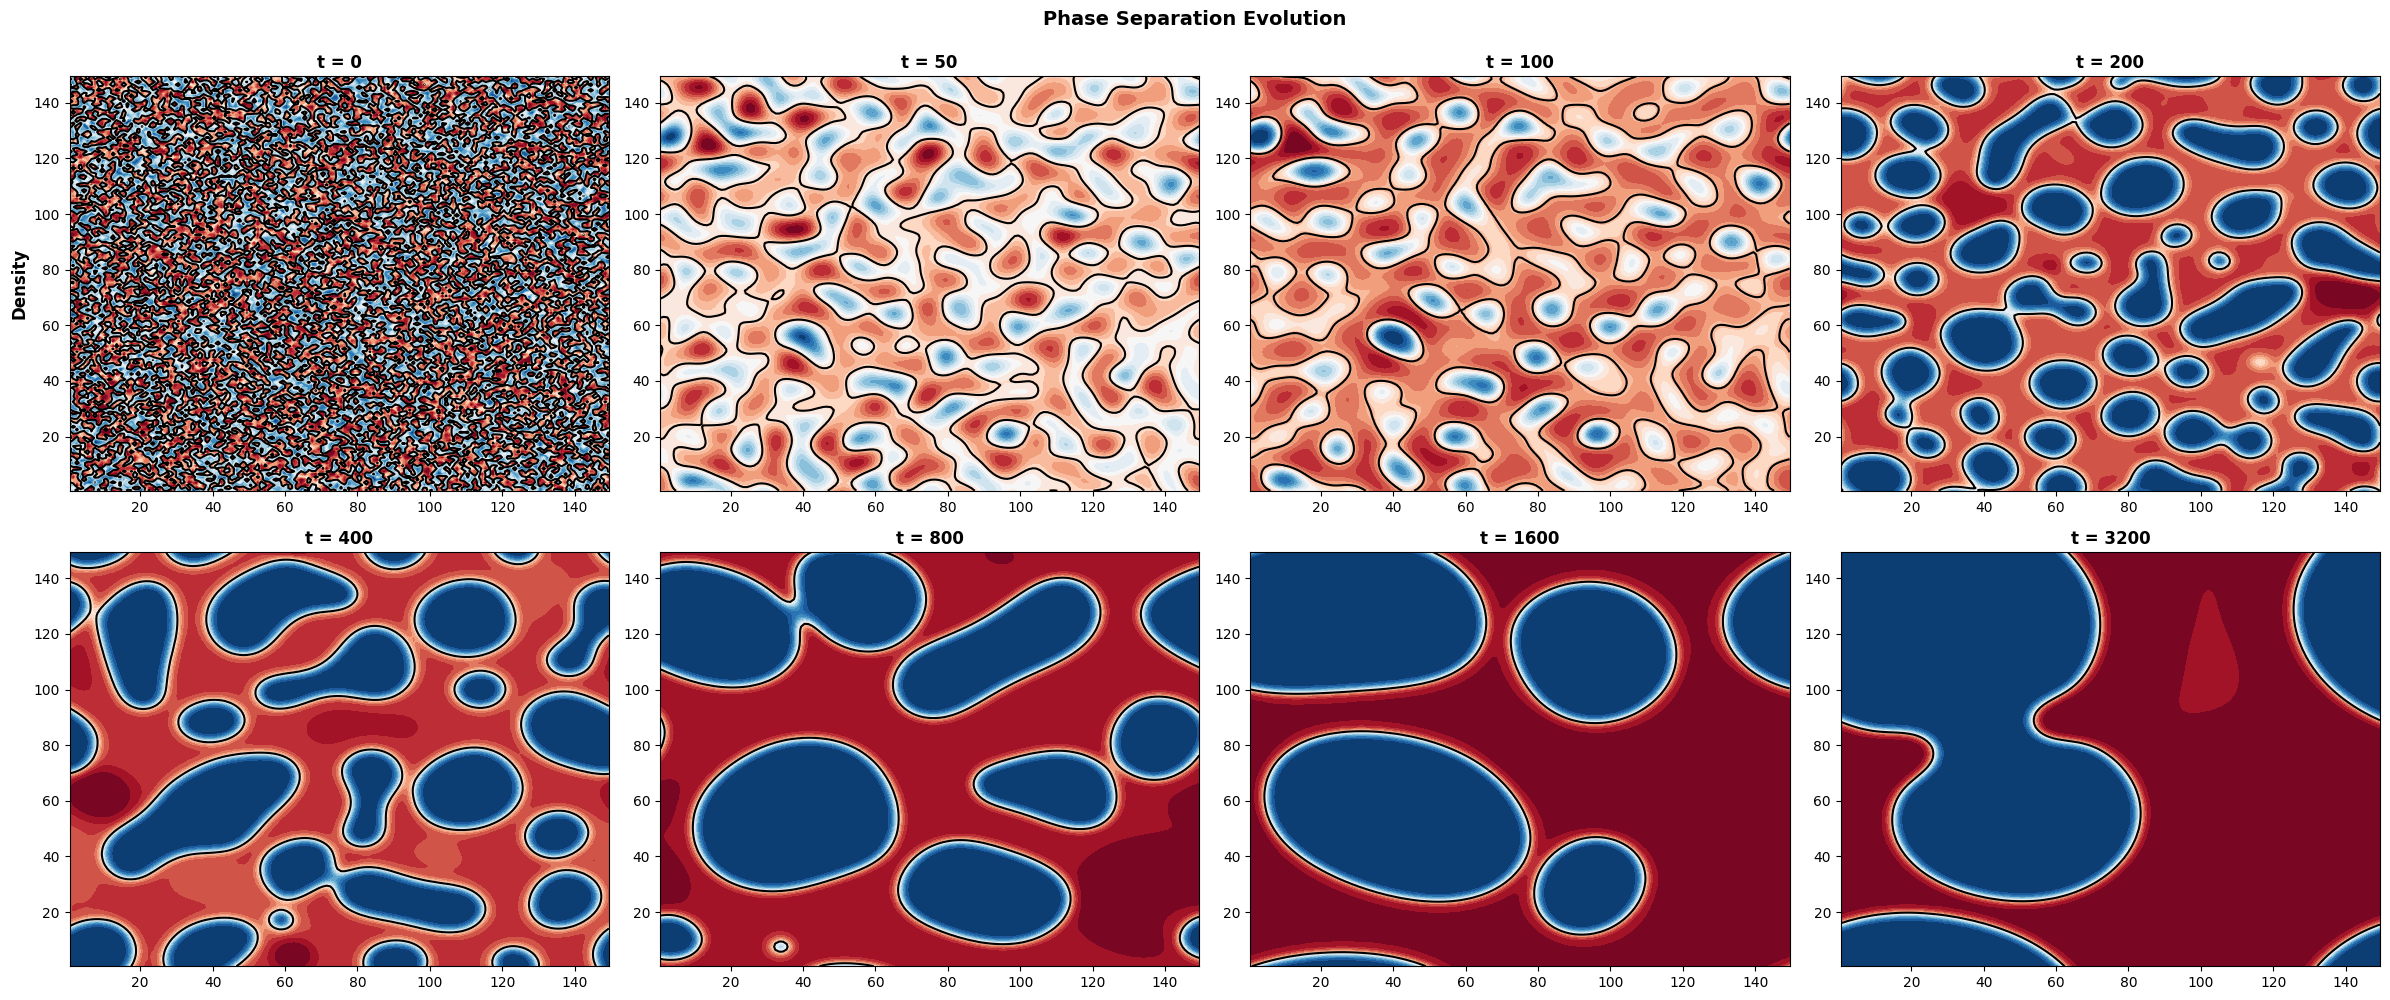

In [ ]:
sim, snapshots = phase_separation(G=-5.2)


# Create visualization
fig, axes = plt.subplots(2, len(snapshots)//2, figsize=(24, 10))

for idx, step in enumerate(snapshots.keys()):
    snap = snapshots[step]
    ax = axes[idx // (len(snapshots)//2), idx % (len(snapshots)//2)]

    # Density field
    levels = np.linspace(snap['rho'].min(), snap['rho'].max(), 20)
    im = ax.contourf(snap['rho'].T, levels=levels, cmap='RdBu_r', origin='lower')
    rho_mean = np.mean(snap['rho'])
    ax.contour(snap['rho'].T, levels=[rho_mean], colors='k', linewidths=1.5, origin='lower')
    ax.set_title(f't = {step}', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    # ax.set_xticks([])
    # ax.set_yticks([])

plt.suptitle('Phase Separation Evolution',
                fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

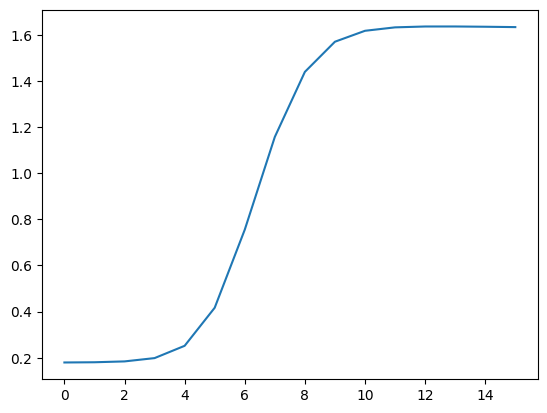

In [38]:
from skimage.measure import profile_line

interface_profile = profile_line(sim.rho, src=(65, 120), dst=(80, 120))
plt.plot(interface_profile)

## Validation Case 2: Contact Angle

In this validation case, we simulate the contact angle between a fluid droplet and a solid interface. The resulting contact angle reflects the balance between fluid-fluid and fluid-solid interaction forces.

The simulation consists of a single fluid droplet placed on a flat solid surface. As a reminder, we model the solid-fluid interaction via a pseudopotential wall force that is parameterized by $G_{ads}$. By varying $G_{ads}$, we observe how the droplet spreads more or less on the solid surface.

In [ ]:
def run_contact_angle_test(G_ads_value, max_steps=5000):
    """
    Initializes and runs a contact angle simulation.

    Parameters:
    ---
    G_ads_value : float
        The fluid-solid interaction strength.
    max_steps : int
        Number of simulation steps to run.
    """
    nx, ny = 256, 128
    n_comp = 2
    omega = [1.0, 1.0]
    G_mat = np.array([[0.0, 7.],
                    [7., 0.0]])
    G_ads = [G_ads_value, -G_ads_value]
    psi_solid = [0.5, 0.5]

    # Bottom wall
    solid_mask = np.zeros((nx, ny), dtype=bool)
    solid_mask[:, 0:2] = True  # y=0 is solid

    # Droplet geometry
    R = 35                                # droplet radius in lattice units
    xc, yc = nx//2, R + 2                  # center above wall so droplet touches at y=1
    Y, X = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')  # careful: (ny,nx)
    # Fields are shaped (nx, ny), so transpose indices
    dist = np.sqrt((X - xc)**2 + (Y - yc)**2)

    # Initialize densities
    rho_init = np.zeros((2, nx, ny), dtype=np.float64)
    inside = dist.T <= R                   # (nx, ny)
    rho_init[0][inside] = 1.0                   # component A inside droplet
    rho_init[1][inside] = 1e-3
    rho_init[0][~inside] = 1e-3                 # component B outside droplet
    rho_init[1][~inside] = 1.0
    rho_init += 1e-6 * np.random.randn(*rho_init.shape)

    solver = LBM_MCMP(nx, ny, n_comp=n_comp, omega=omega, G_mat=G_mat, rho0=[1.0, 1.0],
                    G_ads=G_ads, psi_solid=psi_solid)
    solver.initialize_density_field(rho_init)
    solver.set_solids_from_mask(solid_mask)

    for _ in tqdm(range(max_steps)):
        solver.step()

    return solver


--- Running Contact Angle Test with G_ads = -8.5 ---


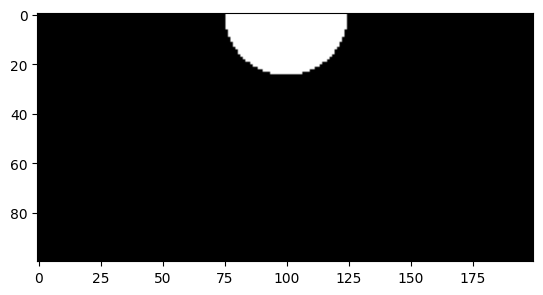

100%|██████████| 5000/5000 [01:52<00:00, 44.57it/s]

Simulation finished.


Text(0, 0.5, 'y')

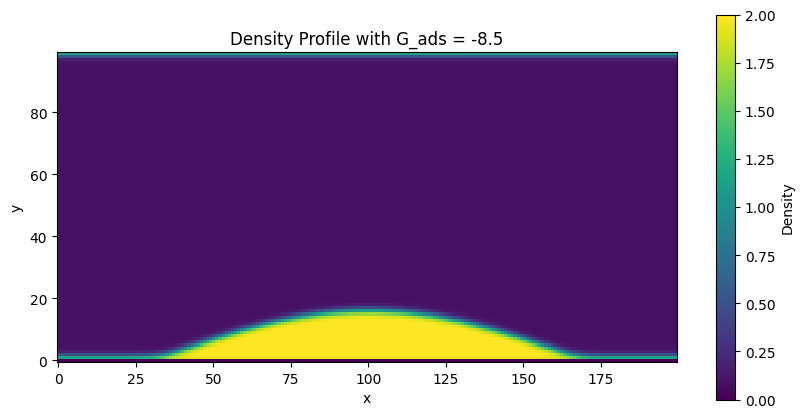

In [ ]:
# --- EXPERIMENT HERE ---
# Change the value of G_ads to see its effect on wettability. Here are some example values:
G_ads_to_test = -3  # (Hydrophilic / Wetting, angle < 90°)
# G_ads_to_test =  0  # (Neutral, angle ≈ 90°)
# G_ads_to_test =  3  # (Hydrophobic / Non-wetting, angle > 90°)

contact_angle_lbm = run_contact_angle_test(G_ads_value=G_ads_to_test, max_steps=5000)

phi = contact_angle_lbm.compute_phase_field()  # shape (nx, ny), indexed [x, y]
nx, ny = contact_angle_lbm.nx, contact_angle_lbm.ny

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(phi.T, origin='lower', extent=[0, nx, 0, ny],
                cmap='RdBu_r', vmin=-1.0, vmax=1.0, interpolation='nearest', aspect='equal')
# Interface: phi = 0 contour
cs = ax.contour(phi.T, levels=[0.0], colors='k', linewidths=1.5, origin='lower', extent=[0, nx, 0, ny])
# Wall overlay (y=0 line)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1.0)  # first fluid row above wall
# Solid mask overlay (light gray)
ax.imshow(contact_angle_lbm.solid_mask.T, origin='lower', extent=[0, nx, 0, ny],
            cmap='gray', alpha=0.15, vmin=0, vmax=1.0)

ax.set_title("Phase field φ with interface (φ=0) contour")
ax.set_xlabel("x")
ax.set_ylabel("y")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("φ")
plt.tight_layout()